# Improved ON/OFF Running-State Scoring System

**Objective**: Improve the median-vote decision procedure by:
1. Evaluating the existing 6-feature voting system
2. Engineering new band-level & scale-invariant features from raw spectrums
3. Data-driven feature selection via statistical association
4. Building an optimised weighted scoring system with tuned thresholds

**Data source**: `data/results.csv` (272 labeled spectrums) + `_results_bundle.pkl` (raw spectrum waveforms)

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, entropy, kurtosis, skew, pointbiserialr, ks_2samp
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, roc_curve
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedGroupKFold
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'src' else os.getcwd()
FIG_DIR = os.path.join(ROOT, 'src', '_scoring_figs')
os.makedirs(FIG_DIR, exist_ok=True)
EPS = 1e-10
BAND_DEFS = [('B1', 30_000, 300_000), ('B2', 300_000, 3_000_000),
             ('B3', 3_000_000, 30_000_000), ('B4', 30_000_000, 100_000_000)]
BANDS = ['B1', 'B2', 'B3', 'B4']

print(f'Root: {ROOT}')

Root: c:\Users\esteban.maestro\Documents\repos\reduced_on_off


## 1 — Data Loading

In [2]:
# Try clean CSV first (old vote columns removed), fall back to original
csv_path = os.path.join(ROOT, 'data', 'results_clean.csv')
if not os.path.exists(csv_path):
    csv_path = os.path.join(ROOT, 'data', 'results.csv')
df_all = pd.read_csv(csv_path)

# Drop old vote columns if still present
old_votes = ['ssn','lr24','clr2','clr4','alr4','lr34','Total']
df_all = df_all.drop(columns=[c for c in old_votes if c in df_all.columns], errors='ignore')

df = df_all.dropna(subset=['running state']).copy().reset_index(drop=True)
df['y'] = (df['running state'] == 'ON').astype(int)
df['org'] = df['site'].str[:3]

with open(os.path.join(ROOT, '_results_bundle.pkl'), 'rb') as fh:
    bundle = pickle.load(fh)
raw_spectrums = bundle['raw_spectrums']

# Fuzzy matching for spectrum IDs
fuzzy_map = {}
for (site, spec_id) in raw_spectrums:
    norm = spec_id.strip().replace('  ', ' ')
    short = norm.split(' \u2013 ')[0].strip() if ' \u2013 ' in norm else norm
    fuzzy_map[(site, norm)] = (site, spec_id)
    fuzzy_map[(site, short)] = (site, spec_id)

def find_raw_key(site, spec_id):
    key = (site, spec_id)
    if key in raw_spectrums:
        return key
    norm = (site, spec_id.strip().replace('  ', ' '))
    if norm in fuzzy_map:
        return fuzzy_map[norm]
    return None

df['_raw_key'] = [find_raw_key(r['site'], str(r['spectrum id'])) for _, r in df.iterrows()]
df['has_raw'] = df['_raw_key'].notna()

print(f'Loaded from: {csv_path}')
print(f'Labeled spectrums : {len(df)}')
print(f'  ON={df["y"].sum()}, OFF={(df["y"]==0).sum()}')
print(f'  Sites: {df["site"].nunique()}')
print(f'  Matched to raw waveforms: {df["has_raw"].sum()}/{len(df)}')

# Sites usable for ON/OFF analysis (need both classes)
usable = df.groupby('site')['y'].nunique()
usable_sites = usable[usable == 2].index.tolist()
print(f'  Sites with both ON and OFF: {len(usable_sites)}')
df[['site','spectrum id','running state','label source','has_raw']].head(10)

Loaded from: c:\Users\esteban.maestro\Documents\repos\reduced_on_off\data\results_clean.csv
Labeled spectrums : 272
  ON=188, OFF=84
  Sites: 38
  Matched to raw waveforms: 272/272
  Sites with both ON and OFF: 28


,site,spectrum id,running state,label source,has_raw
0,WBN2,20251022_1733,ON,cluster,True
1,WBN2,20251102_0839,ON,cluster,True
2,Decatur,20241116_1140,ON,cluster,True
3,Decatur,20241112_1127,ON,cluster,True
4,Decatur,20241102_1259,ON,cluster,True
5,Decatur,20241130_0741,ON,cluster,True
6,Decatur,20241031_1752,ON,cluster,True
7,Decatur,20241031_1852,ON,cluster,True
8,Decatur,20241101_0053,ON,cluster,True
9,Decatur,20241117_0142,ON,cluster,True


## 2 — Evaluate Existing Voting System

In [3]:
from sklearn.metrics import precision_score, recall_score, classification_report

vote_features = ['spectral slope norm', 'lr B2 B4', 'clr B2', 'clr B4', 'alr B4', 'lr B3 B4']

# Reconstruct the original 6-feature median voting system
print('=== Existing Median-Vote System (reconstructed) ===')
print(f'Features used: {vote_features}')
# Cohen's d sign determines vote direction
old_directions = {
    'spectral slope norm': 'lower',
    'lr B2 B4': 'higher',
    'clr B2': 'higher',
    'clr B4': 'lower',
    'alr B4': 'higher',
    'lr B3 B4': 'higher',
}

df['_old_total'] = 0.0
for feat in vote_features:
    if feat not in df.columns:
        print(f'  WARNING: {feat} not in data')
        continue
    med = df[feat].median()
    if old_directions[feat] == 'higher':
        df['_old_total'] += (df[feat] >= med).astype(float)
    else:
        df['_old_total'] += (df[feat] < med).astype(float)

print(f'Total score range: {df["_old_total"].min():.0f} – {df["_old_total"].max():.0f}')
print()

print('Accuracy by threshold (Total >= T → ON):')
best_acc, best_t = 0, 0
for t in range(7):
    pred = (df['_old_total'] >= t).astype(int)
    acc = accuracy_score(df['y'], pred)
    f1 = f1_score(df['y'], pred, zero_division=0)
    print(f'  T={t}: acc={acc:.3f}, F1={f1:.3f}')
    if acc > best_acc:
        best_acc, best_t = acc, t

pred_best = (df['_old_total'] >= best_t).astype(int)
cm = confusion_matrix(df['y'], pred_best)
print(f'\nBest threshold T={best_t}: accuracy={best_acc:.3f}')
print(f'Confusion matrix (rows=true, cols=pred):\n{cm}')
print(f'\nClassification report:')
print(classification_report(df['y'], pred_best, target_names=['OFF','ON']))

=== Existing Median-Vote System (reconstructed) ===
Features used: ['spectral slope norm', 'lr B2 B4', 'clr B2', 'clr B4', 'alr B4', 'lr B3 B4']
Total score range: 0 – 6

Accuracy by threshold (Total >= T → ON):
  T=0: acc=0.691, F1=0.817
  T=1: acc=0.790, F1=0.853
  T=2: acc=0.757, F1=0.817
  T=3: acc=0.688, F1=0.745
  T=4: acc=0.669, F1=0.715
  T=5: acc=0.621, F1=0.648
  T=6: acc=0.467, F1=0.393

Best threshold T=1: accuracy=0.790
Confusion matrix (rows=true, cols=pred):
[[ 49  35]
 [ 22 166]]

Classification report:
              precision    recall  f1-score   support

         OFF       0.69      0.58      0.63        84
          ON       0.83      0.88      0.85       188

    accuracy                           0.79       272
   macro avg       0.76      0.73      0.74       272
weighted avg       0.78      0.79      0.79       272



In [4]:
# Per-site accuracy of existing system
site_results = []
for site, grp in df.groupby('site'):
    if grp['y'].nunique() < 2:
        continue
    pred = (grp['_old_total'] >= best_t).astype(int)
    site_results.append({
        'site': site, 'n': len(grp),
        'n_ON': grp['y'].sum(), 'n_OFF': (grp['y']==0).sum(),
        'accuracy': accuracy_score(grp['y'], pred),
        'f1': f1_score(grp['y'], pred, zero_division=0)
    })
df_site_old = pd.DataFrame(site_results).sort_values('accuracy')
print('Per-site accuracy (existing system, sites with both ON & OFF):')
print(df_site_old.to_string(index=False))

Per-site accuracy (existing system, sites with both ON & OFF):
         site  n  n_ON  n_OFF  accuracy       f1
     AEP_Turk  2     1      1  0.000000 0.000000
         WBN2  4     3      1  0.000000 0.000000
 Towantic_GT2  3     2      1  0.333333 0.500000
  EMSA_GT2_NG  3     2      1  0.333333 0.500000
     Harq_ST1 10     7      3  0.400000 0.250000
      HARQST1  2     1      1  0.500000 0.000000
      HARQST3  2     1      1  0.500000 0.000000
  EMSA_GT1_ng  2     1      1  0.500000 0.666667
 Towantic_GT1  2     1      1  0.500000 0.666667
      Van_GT3 19     3     16  0.526316 0.400000
         SQN2 15    10      5  0.666667 0.800000
Middletown_ST  3     2      1  0.666667 0.800000
     Harq_ST3  9     5      4  0.666667 0.571429
      Van_GT2 20    18      2  0.700000 0.823529
  Harq_ST2_PT 10     7      3  0.700000 0.823529
  Harq_ST1_PT 10     7      3  0.700000 0.823529
Middletown_GT  7     5      2  0.714286 0.833333
         VAN1 10     5      5  0.900000 0.909091
      

## 3 — New Feature Engineering from Raw Spectrums

Compute band-level and scale-invariant features that capture within-band spectral shape.

In [5]:
def compute_band_features(freqs, amplitudes_uv):
    """Compute per-band and cross-band scale-invariant features from raw spectrum."""
    pwr = amplitudes_uv ** 2
    log_f = np.log(freqs + EPS)
    log_p = np.log(pwr + EPS)
    feat = {}

    band_masks = {}
    band_pwr = {}
    band_logp = {}
    band_logf = {}

    for bn, lo, hi in BAND_DEFS:
        mask = (freqs >= lo) & (freqs < hi)
        band_masks[bn] = mask
        band_pwr[bn] = pwr[mask]
        band_logp[bn] = log_p[mask]
        band_logf[bn] = log_f[mask]

    # --- Per-band spectral slope (log-log, scale-invariant) ---
    for bn in BANDS:
        lf, lp = band_logf[bn], band_logp[bn]
        if len(lf) > 1:
            slope, intercept = np.polyfit(lf, lp, 1)
            feat[f'slope_loglog_{bn}'] = slope
            residuals = lp - (slope * lf + intercept)
            feat[f'slope_r2_{bn}'] = 1 - np.var(residuals) / (np.var(lp) + EPS)
        else:
            feat[f'slope_loglog_{bn}'] = 0.0
            feat[f'slope_r2_{bn}'] = 0.0

    # --- Per-band spectral curvature (2nd-order poly in log-log) ---
    for bn in BANDS:
        lf, lp = band_logf[bn], band_logp[bn]
        if len(lf) > 2:
            c2, _, _ = np.polyfit(lf, lp, 2)
            feat[f'curvature_{bn}'] = c2
        else:
            feat[f'curvature_{bn}'] = 0.0

    # --- Per-band entropy (scale-invariant via normalisation) ---
    for bn in BANDS:
        bp = band_pwr[bn]
        if len(bp) > 0 and bp.sum() > 0:
            normp = bp / bp.sum()
            normp = np.clip(normp, 1e-20, None)
            feat[f'entropy_{bn}'] = entropy(normp) / np.log(len(bp))
        else:
            feat[f'entropy_{bn}'] = 0.0

    # --- Per-band spectral flatness (scale-invariant) ---
    for bn in BANDS:
        bp = band_pwr[bn]
        if len(bp) > 0 and bp.mean() > 0:
            log_mean = np.mean(np.log(bp + EPS))
            feat[f'flatness_{bn}'] = np.exp(log_mean) / (bp.mean() + EPS)
        else:
            feat[f'flatness_{bn}'] = 0.0

    # --- Per-band coefficient of variation (scale-invariant) ---
    for bn in BANDS:
        bp = band_pwr[bn]
        if len(bp) > 0 and bp.mean() > 0:
            feat[f'cv_{bn}'] = bp.std() / (bp.mean() + EPS)
        else:
            feat[f'cv_{bn}'] = 0.0

    # --- Per-band peak-to-mean ratio (scale-invariant) ---
    for bn in BANDS:
        bp = band_pwr[bn]
        if len(bp) > 0 and bp.mean() > 0:
            feat[f'peak_ratio_{bn}'] = bp.max() / (bp.mean() + EPS)
        else:
            feat[f'peak_ratio_{bn}'] = 0.0

    # --- Per-band crest factor (scale-invariant) ---
    for bn in BANDS:
        ba = amplitudes_uv[band_masks[bn]]
        if len(ba) > 0:
            rms = np.sqrt(np.mean(ba**2))
            feat[f'crest_{bn}'] = ba.max() / (rms + EPS)
        else:
            feat[f'crest_{bn}'] = 0.0

    # --- Inter-band transition ratios (power at boundary zones) ---
    boundaries = [
        ('trans_B1_B2', 300_000),
        ('trans_B2_B3', 3_000_000),
        ('trans_B3_B4', 30_000_000),
    ]
    for name, freq_boundary in boundaries:
        width = freq_boundary * 0.1
        below = pwr[(freqs >= freq_boundary - width) & (freqs < freq_boundary)]
        above = pwr[(freqs >= freq_boundary) & (freqs < freq_boundary + width)]
        if len(below) > 0 and len(above) > 0:
            feat[name] = np.log(above.mean() + EPS) - np.log(below.mean() + EPS)
        else:
            feat[name] = 0.0

    # --- Slope differences between adjacent bands ---
    for i in range(len(BANDS)-1):
        b1, b2 = BANDS[i], BANDS[i+1]
        feat[f'slope_diff_{b1}_{b2}'] = feat[f'slope_loglog_{b2}'] - feat[f'slope_loglog_{b1}']

    # --- Global scale-invariant: spectral centroid on normalised spectrum ---
    normp_global = pwr / (pwr.sum() + EPS)
    freq_mhz = freqs / 1e6
    feat['centroid_mhz_norm'] = np.sum(freq_mhz * normp_global)

    # --- Energy concentration: fraction of energy in top 10% of bins ---
    sorted_pwr = np.sort(pwr)[::-1]
    n10 = max(1, len(pwr) // 10)
    feat['energy_concentration'] = sorted_pwr[:n10].sum() / (pwr.sum() + EPS)

    # --- Spectral rolloff per band (85% energy frequency, normalised to band range) ---
    for bn, lo, hi in BAND_DEFS:
        bp = band_pwr[bn]
        bf = freqs[band_masks[bn]]
        if len(bp) > 0 and bp.sum() > 0:
            cumsum = np.cumsum(bp)
            idx = np.searchsorted(cumsum, 0.85 * bp.sum())
            idx = min(idx, len(bf) - 1)
            feat[f'rolloff_norm_{bn}'] = (bf[idx] - lo) / (hi - lo + EPS)
        else:
            feat[f'rolloff_norm_{bn}'] = 0.5

    # --- Band energy ratios in log space (already in CSV but recompute for consistency) ---
    total_band_powers = {bn: band_pwr[bn].sum() for bn in BANDS}
    log_bp = {bn: np.log(total_band_powers[bn] + EPS) for bn in BANDS}
    geo_mean = np.mean([log_bp[bn] for bn in BANDS])

    # spectral_slope_norm per band: slope_loglog / |geo_mean|
    for bn in BANDS:
        feat[f'ssn_{bn}'] = feat[f'slope_loglog_{bn}'] / (abs(geo_mean) + EPS)

    return feat

print('Feature function defined. Computing...')

Feature function defined. Computing...


In [6]:
new_feat_rows = []
skipped = 0
for idx, row in df.iterrows():
    raw_key = row['_raw_key']
    if raw_key is None or raw_key not in raw_spectrums:
        new_feat_rows.append({})
        skipped += 1
        continue
    freqs, amps = raw_spectrums[raw_key]
    new_feat_rows.append(compute_band_features(freqs, amps))

df_new = pd.DataFrame(new_feat_rows, index=df.index)
new_feature_cols = [c for c in df_new.columns if df_new[c].notna().sum() > 0]
print(f'Computed {len(new_feature_cols)} new features for {len(df)-skipped} spectrums (skipped {skipped})')
print(f'New features: {new_feature_cols}')

Computed 48 new features for 272 spectrums (skipped 0)
New features: ['slope_loglog_B1', 'slope_r2_B1', 'slope_loglog_B2', 'slope_r2_B2', 'slope_loglog_B3', 'slope_r2_B3', 'slope_loglog_B4', 'slope_r2_B4', 'curvature_B1', 'curvature_B2', 'curvature_B3', 'curvature_B4', 'entropy_B1', 'entropy_B2', 'entropy_B3', 'entropy_B4', 'flatness_B1', 'flatness_B2', 'flatness_B3', 'flatness_B4', 'cv_B1', 'cv_B2', 'cv_B3', 'cv_B4', 'peak_ratio_B1', 'peak_ratio_B2', 'peak_ratio_B3', 'peak_ratio_B4', 'crest_B1', 'crest_B2', 'crest_B3', 'crest_B4', 'trans_B1_B2', 'trans_B2_B3', 'trans_B3_B4', 'slope_diff_B1_B2', 'slope_diff_B2_B3', 'slope_diff_B3_B4', 'centroid_mhz_norm', 'energy_concentration', 'rolloff_norm_B1', 'rolloff_norm_B2', 'rolloff_norm_B3', 'rolloff_norm_B4', 'ssn_B1', 'ssn_B2', 'ssn_B3', 'ssn_B4']


In [7]:
# Merge new features into main dataframe
df = pd.concat([df, df_new], axis=1)

# Combine original + new feature columns for analysis
original_feat_cols = [
    'spectral slope norm', 'lr B2 B4', 'clr B2', 'clr B4', 'alr B4', 'lr B3 B4',
    'lr B1 B4', 'ilr 3', 'band gradient proper',
    'spectral slope', 'spectral entropy', 'spectral flatness',
    'spectral centroid', 'spectral spread', 'spectral kurtosis', 'spectral skew',
    'peak to mean', 'crest factor', 'band gradient', 'band range',
    'B4 B2 ratio', 'B3 B2 ratio', 'B2 B1 ratio', 'B4 B1 ratio',
    'hi lo ratio', 'log hi lo', 'log B2 B1', 'log B4 B1',
    'B4 frac',
]
# Keep only columns that exist
original_feat_cols = [c for c in original_feat_cols if c in df.columns]

all_feat_cols = original_feat_cols + new_feature_cols
print(f'Total features for analysis: {len(all_feat_cols)} ({len(original_feat_cols)} original + {len(new_feature_cols)} new)')

Total features for analysis: 77 (29 original + 48 new)


## 4 — Univariate Statistical Association Analysis

For every feature, compute Mann-Whitney U, Cohen's d, ROC-AUC, and point-biserial correlation against the ON/OFF label.

In [8]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*np.var(x,ddof=1) + (ny-1)*np.var(y,ddof=1)) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / (pooled_std + EPS)

# Only use rows with raw spectrum data (non-NaN new features)
mask_valid = df['has_raw']
dfa = df[mask_valid].copy()
y_a = dfa['y'].values
on_mask = y_a == 1
off_mask = y_a == 0

stats_rows = []
for col in all_feat_cols:
    vals = dfa[col].values.astype(float)
    valid = ~np.isnan(vals)
    if valid.sum() < 10:
        continue
    v = vals[valid]
    y_v = y_a[valid]
    on_vals = v[y_v == 1]
    off_vals = v[y_v == 0]
    if len(on_vals) < 3 or len(off_vals) < 3:
        continue

    stat_mw, p_mw = mannwhitneyu(on_vals, off_vals, alternative='two-sided')
    d = cohens_d(on_vals, off_vals)
    try:
        auc = roc_auc_score(y_v, v)
    except:
        auc = 0.5
    r_pb, p_pb = pointbiserialr(y_v, v)
    ks_stat, p_ks = ks_2samp(on_vals, off_vals)

    stats_rows.append({
        'feature': col,
        'source': 'new' if col in new_feature_cols else 'original',
        'mean_ON': on_vals.mean(),
        'mean_OFF': off_vals.mean(),
        'cohen_d': d,
        'abs_d': abs(d),
        'AUC': auc,
        'AUC_abs': max(auc, 1-auc),
        'MW_p': p_mw,
        'r_pointbiserial': r_pb,
        'KS_stat': ks_stat,
        'KS_p': p_ks,
    })

df_stats = pd.DataFrame(stats_rows)

# BH correction for multiple testing
reject, pvals_corrected, _, _ = multipletests(df_stats['MW_p'], alpha=0.05, method='fdr_bh')
df_stats['MW_p_BH'] = pvals_corrected
df_stats['significant'] = reject

df_stats = df_stats.sort_values('abs_d', ascending=False).reset_index(drop=True)
print(f'Tested {len(df_stats)} features. Significant (BH-corrected p<0.05): {df_stats["significant"].sum()}')
print()
print(df_stats[['feature','source','cohen_d','AUC_abs','MW_p_BH','significant','mean_ON','mean_OFF']].head(30).to_string(index=False))

Tested 77 features. Significant (BH-corrected p<0.05): 52

             feature   source   cohen_d  AUC_abs      MW_p_BH  significant    mean_ON    mean_OFF
              ssn_B1      new  0.855505 0.678951 9.078095e-06         True  -0.078124   -0.158045
            lr B2 B4 original  0.841093 0.753894 5.787015e-10         True   3.414142    0.515540
               ilr 3 original  0.837810 0.747404 1.065596e-09         True   2.495660    0.526943
              clr B4 original -0.837663 0.747720 1.065596e-09         True  -2.161243   -0.456458
              clr B2 original  0.777750 0.746549 1.065596e-09         True   1.252740    0.058845
              alr B4 original  0.760504 0.710265 2.602525e-07         True   7.075208    4.497487
    slope_diff_B1_B2      new -0.756985 0.689906 2.722166e-06         True  -1.849017   -0.145444
     rolloff_norm_B3      new -0.742666 0.689241 2.794315e-06         True   0.529822    0.744857
     spectral spread original -0.715190 0.678445 9.078095e-

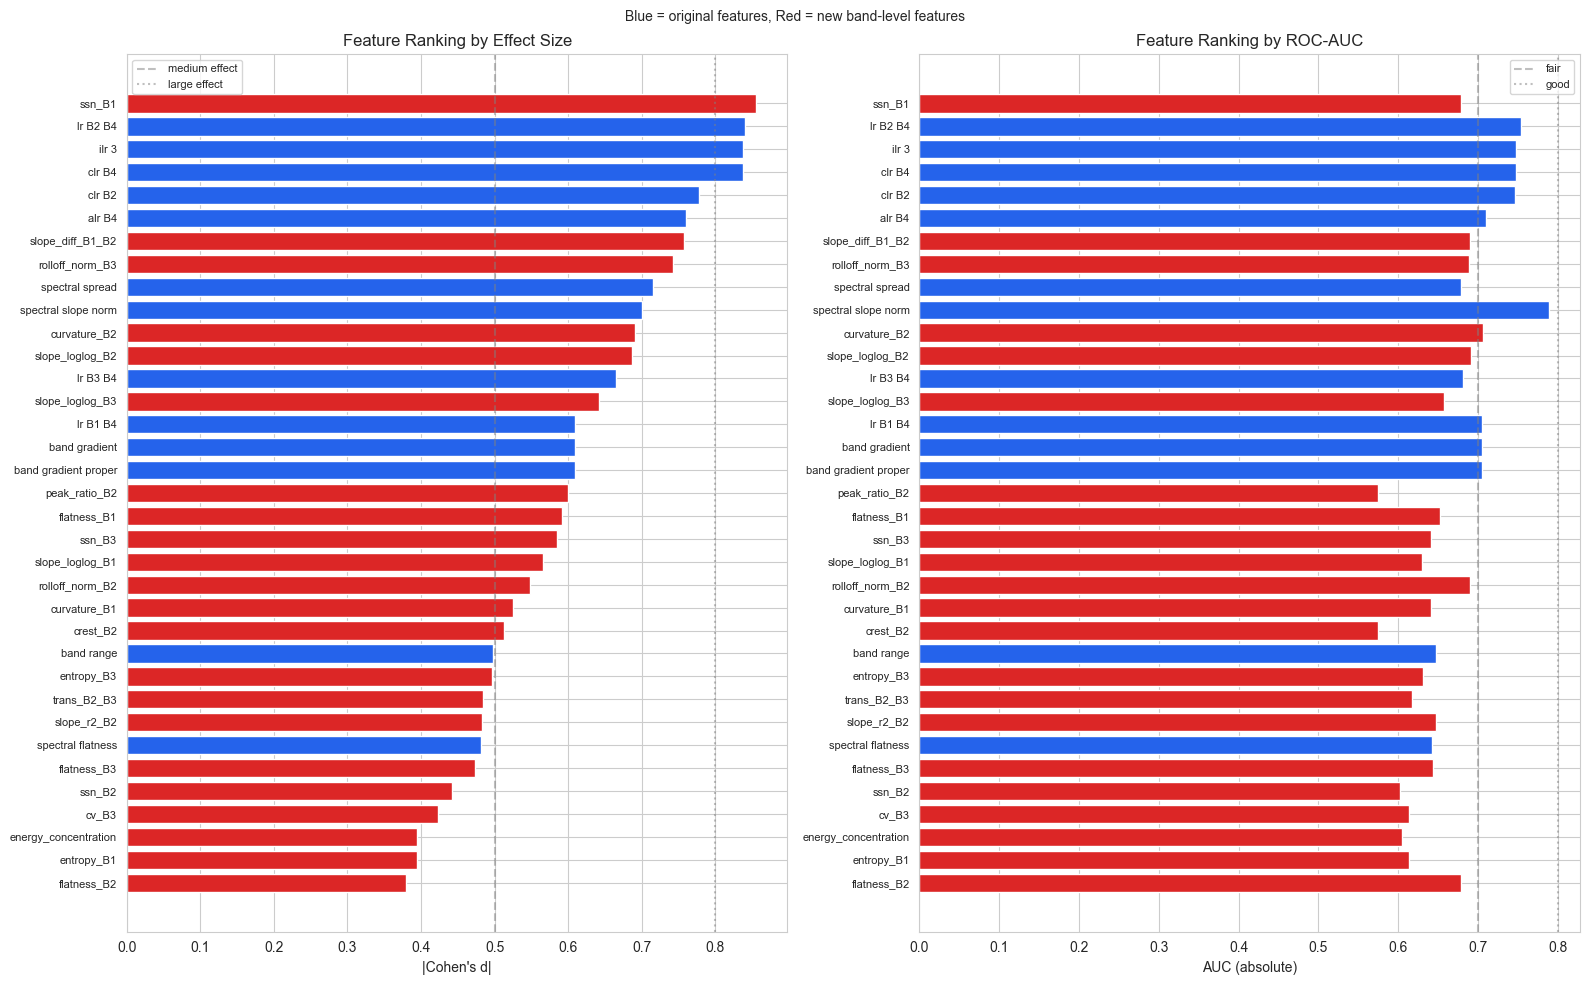

In [9]:
# Top features plot
top_n = min(35, len(df_stats))
df_top = df_stats.head(top_n).copy()
colors = ['#2563eb' if s == 'original' else '#dc2626' for s in df_top['source']]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

axes[0].barh(range(top_n), df_top['abs_d'].values, color=colors)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(df_top['feature'].values, fontsize=8)
axes[0].set_xlabel('|Cohen\'s d|')
axes[0].set_title('Feature Ranking by Effect Size')
axes[0].invert_yaxis()
axes[0].axvline(0.5, color='grey', ls='--', alpha=0.5, label='medium effect')
axes[0].axvline(0.8, color='grey', ls=':', alpha=0.5, label='large effect')
axes[0].legend(fontsize=8)

axes[1].barh(range(top_n), df_top['AUC_abs'].values, color=colors)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(df_top['feature'].values, fontsize=8)
axes[1].set_xlabel('AUC (absolute)')
axes[1].set_title('Feature Ranking by ROC-AUC')
axes[1].invert_yaxis()
axes[1].axvline(0.7, color='grey', ls='--', alpha=0.5, label='fair')
axes[1].axvline(0.8, color='grey', ls=':', alpha=0.5, label='good')
axes[1].legend(fontsize=8)

fig.suptitle('Blue = original features, Red = new band-level features', fontsize=10, y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'feature_ranking.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5 — Correlation Analysis & Redundancy Removal

52 significant features


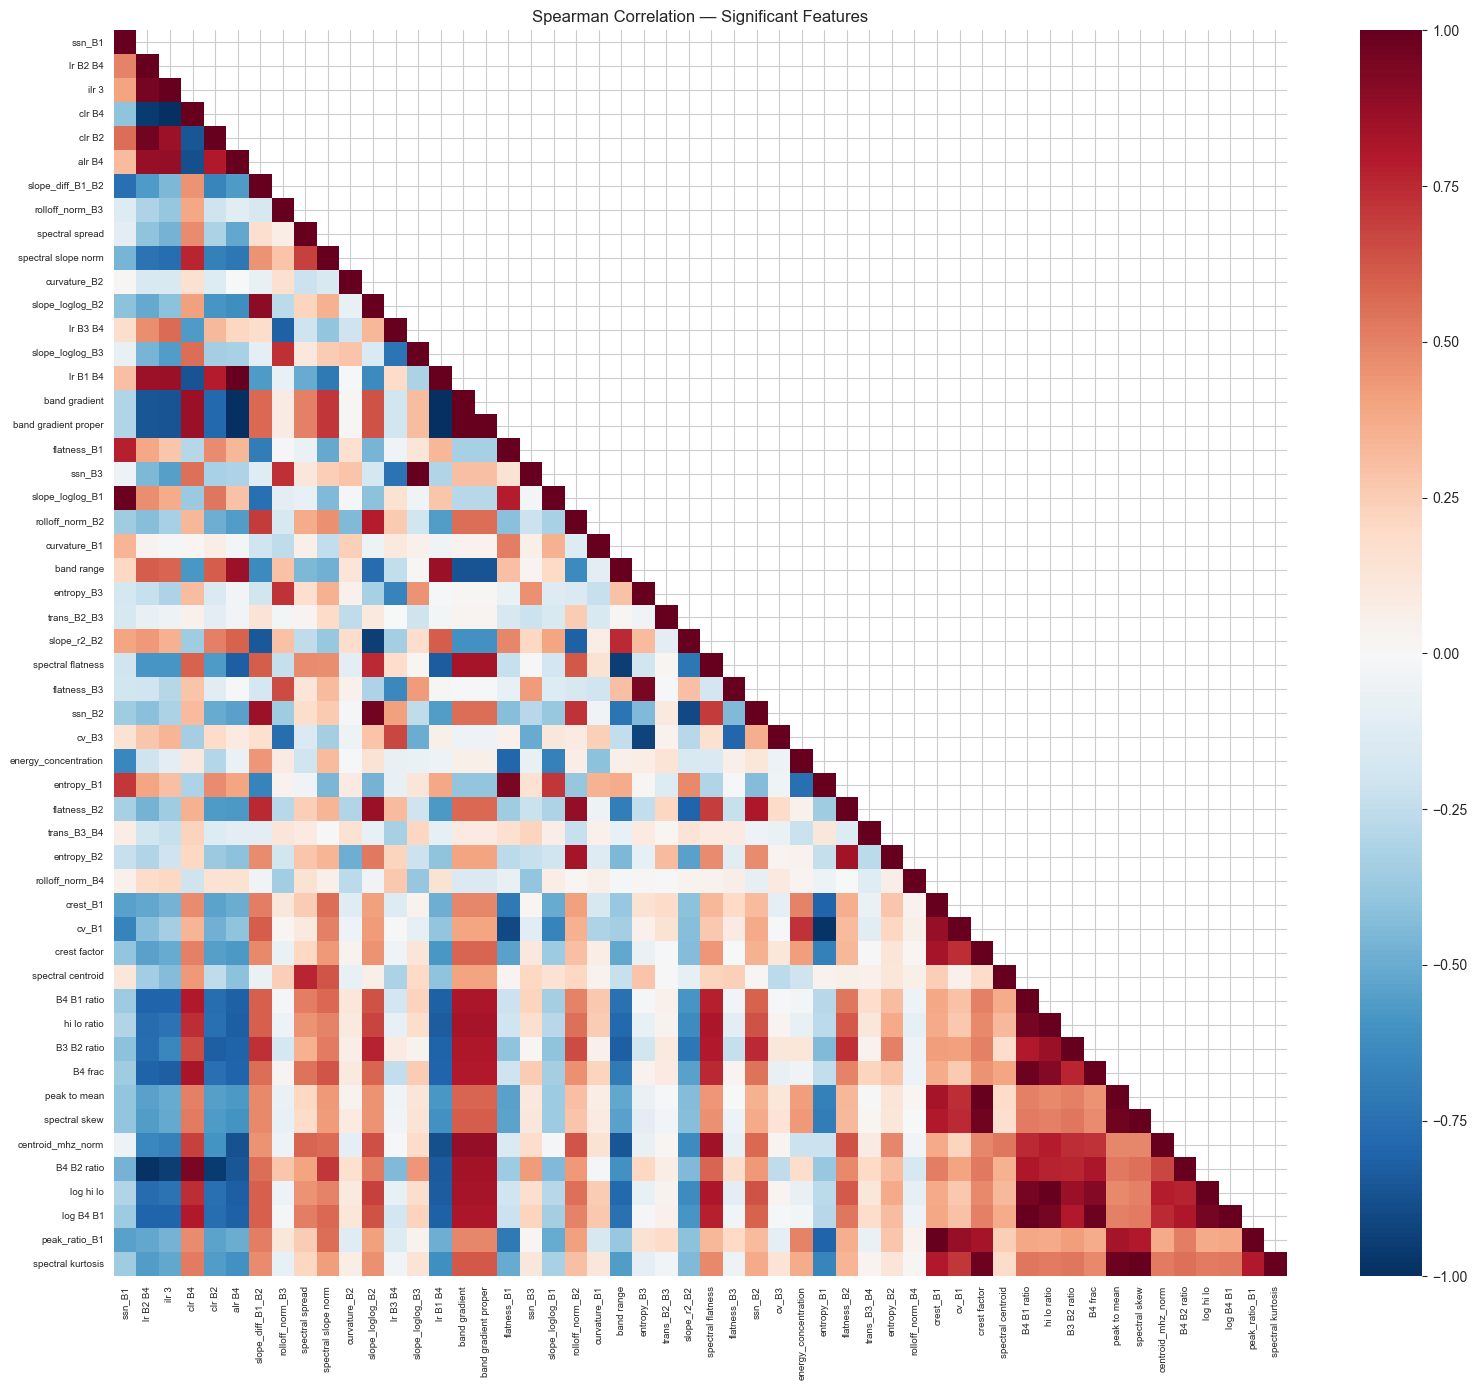

In [10]:
# Select significant features for correlation analysis
sig_feats = df_stats[df_stats['significant']]['feature'].tolist()
print(f'{len(sig_feats)} significant features')

corr_data = dfa[sig_feats].dropna(axis=1, how='all').astype(float)
corr_matrix = corr_data.corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Spearman Correlation — Significant Features')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Remove highly correlated features (keep the one with higher |Cohen's d|)
CORR_THRESHOLD = 0.85

d_rank = df_stats.set_index('feature')['abs_d'].to_dict()
sig_feats_sorted = sorted(sig_feats, key=lambda f: d_rank.get(f, 0), reverse=True)

selected = []
dropped = []
for feat in sig_feats_sorted:
    if feat not in corr_matrix.columns:
        continue
    redundant = False
    for sel in selected:
        if sel in corr_matrix.columns and feat in corr_matrix.index:
            if abs(corr_matrix.loc[feat, sel]) > CORR_THRESHOLD:
                redundant = True
                dropped.append((feat, sel, corr_matrix.loc[feat, sel]))
                break
    if not redundant:
        selected.append(feat)

print(f'After removing correlated pairs (|r| > {CORR_THRESHOLD}):')
print(f'  Selected: {len(selected)} features')
print(f'  Dropped: {len(dropped)} features')
print()
print('Selected features (ranked by |Cohen\'s d|):')
for i, f in enumerate(selected):
    row = df_stats[df_stats['feature'] == f].iloc[0]
    print(f'  {i+1:2d}. {f:30s}  d={row["cohen_d"]:+.3f}  AUC={row["AUC_abs"]:.3f}  src={row["source"]}')
print()
print('Dropped pairs:')
for feat, kept, r in dropped[:15]:
    print(f'  {feat:30s} correlated with {kept:30s} (r={r:.2f})')

After removing correlated pairs (|r| > 0.85):
  Selected: 25 features
  Dropped: 27 features

Selected features (ranked by |Cohen's d|):
   1. ssn_B1                          d=+0.856  AUC=0.679  src=new
   2. lr B2 B4                        d=+0.841  AUC=0.754  src=original
   3. slope_diff_B1_B2                d=-0.757  AUC=0.690  src=new
   4. rolloff_norm_B3                 d=-0.743  AUC=0.689  src=new
   5. spectral spread                 d=-0.715  AUC=0.678  src=original
   6. spectral slope norm             d=-0.700  AUC=0.789  src=original
   7. curvature_B2                    d=+0.691  AUC=0.706  src=new
   8. lr B3 B4                        d=+0.665  AUC=0.681  src=original
   9. slope_loglog_B3                 d=-0.642  AUC=0.657  src=new
  10. flatness_B1                     d=+0.591  AUC=0.652  src=new
  11. rolloff_norm_B2                 d=-0.548  AUC=0.690  src=new
  12. curvature_B1                    d=+0.525  AUC=0.641  src=new
  13. band range                      d

## 6 — Improved Scoring System

Three improvements over median-vote:
1. **Optimal threshold** per feature (Youden's J statistic)
2. **Weighted votes** based on Cohen's d effect size
3. **Data-driven feature set** (non-redundant significant features)

In [12]:
def find_optimal_threshold(values, labels):
    """Find threshold maximising Youden's J = sensitivity + specificity - 1."""
    valid = ~np.isnan(values)
    v, y = values[valid], labels[valid]
    auc = roc_auc_score(y, v)
    if auc < 0.5:
        v = -v
        flip = True
    else:
        flip = False
    fpr, tpr, thresholds = roc_curve(y, v)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    if flip:
        return -best_threshold, 'lower'
    else:
        return best_threshold, 'higher'

# Build scoring system on the analysis subset
scoring_features = selected.copy()
scoring_params = []

for feat in scoring_features:
    vals = dfa[feat].values.astype(float)
    threshold, direction = find_optimal_threshold(vals, y_a)
    d_val = df_stats[df_stats['feature'] == feat]['cohen_d'].values[0]
    weight = abs(d_val)
    scoring_params.append({
        'feature': feat,
        'threshold': threshold,
        'direction': direction,
        'weight': weight,
        'cohen_d': d_val,
    })

df_scoring = pd.DataFrame(scoring_params)
print('Scoring parameters:')
print(df_scoring.to_string(index=False))

Scoring parameters:
             feature  threshold direction   weight   cohen_d
              ssn_B1  -0.100860    higher 0.855505  0.855505
            lr B2 B4   1.610000    higher 0.841093  0.841093
    slope_diff_B1_B2  -0.845839     lower 0.756985 -0.756985
     rolloff_norm_B3   0.663500     lower 0.742666 -0.742666
     spectral spread 724.790000     lower 0.715190 -0.715190
 spectral slope norm  -0.001600     lower 0.700005 -0.700005
        curvature_B2   0.203350    higher 0.691025  0.691025
            lr B3 B4  -1.760000    higher 0.665422  0.665422
     slope_loglog_B3  -0.967484     lower 0.642236 -0.642236
         flatness_B1   0.310824    higher 0.591387  0.591387
     rolloff_norm_B2   0.288000     lower 0.547711 -0.547711
        curvature_B1  -1.161160    higher 0.524808  0.524808
          band range   7.600000    higher 0.497906  0.497906
          entropy_B3   0.846180     lower 0.495817 -0.495817
         trans_B2_B3  -0.017365     lower 0.483635 -0.483635
    

In [13]:
def compute_scores(data, params_df, mode='weighted'):
    """Compute ON-score for each spectrum.
    mode='unweighted': simple vote count (0 or 1 per feature)
    mode='weighted': vote * |Cohen's d| weight
    """
    scores = np.zeros(len(data))
    max_possible = 0
    for _, p in params_df.iterrows():
        vals = data[p['feature']].values.astype(float)
        if p['direction'] == 'higher':
            vote = (vals >= p['threshold']).astype(float)
        else:
            vote = (vals <= p['threshold']).astype(float)
        vote[np.isnan(vals)] = np.nan
        w = p['weight'] if mode == 'weighted' else 1.0
        scores += vote * w
        max_possible += w
    return scores, max_possible

# Compute both scoring modes
scores_w, max_w = compute_scores(dfa, df_scoring, mode='weighted')
scores_u, max_u = compute_scores(dfa, df_scoring, mode='unweighted')

# Normalise to [0, 1]
scores_w_norm = scores_w / (max_w + EPS)
scores_u_norm = scores_u / (max_u + EPS)

# Find optimal global threshold for each
def best_threshold_scan(scores_norm, y_true):
    best_acc, best_t, best_f1 = 0, 0.5, 0
    for t in np.arange(0.05, 0.96, 0.01):
        pred = (scores_norm >= t).astype(int)
        acc = accuracy_score(y_true, pred)
        f1 = f1_score(y_true, pred, zero_division=0)
        if acc > best_acc:
            best_acc, best_t, best_f1 = acc, t, f1
    return best_t, best_acc, best_f1

t_w, acc_w, f1_w = best_threshold_scan(scores_w_norm, y_a)
t_u, acc_u, f1_u = best_threshold_scan(scores_u_norm, y_a)

# Original system for comparison
orig_total = dfa['_old_total'].values
orig_pred = (orig_total >= best_t).astype(int)
acc_orig = accuracy_score(y_a, orig_pred)
f1_orig = f1_score(y_a, orig_pred, zero_division=0)
try:
    auc_orig = roc_auc_score(y_a, orig_total)
except:
    auc_orig = 0.5

auc_w = roc_auc_score(y_a, scores_w_norm)
auc_u = roc_auc_score(y_a, scores_u_norm)

print('=== System Comparison (in-sample) ===')
print(f'  Original 6-feat median-vote : acc={acc_orig:.3f}  F1={f1_orig:.3f}  AUC={auc_orig:.3f}')
print(f'  Improved unweighted vote    : acc={acc_u:.3f}  F1={f1_u:.3f}  AUC={auc_u:.3f}  (threshold={t_u:.2f})')
print(f'  Improved weighted vote      : acc={acc_w:.3f}  F1={f1_w:.3f}  AUC={auc_w:.3f}  (threshold={t_w:.2f})')

=== System Comparison (in-sample) ===
  Original 6-feat median-vote : acc=0.790  F1=0.853  AUC=0.794
  Improved unweighted vote    : acc=0.827  F1=0.875  AUC=0.908  (threshold=0.32)
  Improved weighted vote      : acc=0.835  F1=0.877  AUC=0.906  (threshold=0.40)


## 7 — Cross-Validated Evaluation

Use StratifiedGroupKFold (5-fold, site-aware) to get honest out-of-fold performance estimates, avoiding data leakage.

In [14]:
# Prepare cross-validation
groups = dfa['site'].values
n_splits = 5
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_results = {'original': [], 'unweighted': [], 'weighted': []}
oof_preds = {'original': np.zeros(len(dfa)), 'unweighted': np.zeros(len(dfa)), 'weighted': np.zeros(len(dfa))}
oof_scores = {'original': np.zeros(len(dfa)), 'unweighted': np.zeros(len(dfa)), 'weighted': np.zeros(len(dfa))}

for fold, (train_idx, val_idx) in enumerate(sgkf.split(dfa, y_a, groups)):
    y_train, y_val = y_a[train_idx], y_a[val_idx]
    df_train, df_val = dfa.iloc[train_idx], dfa.iloc[val_idx]

    # --- Original system (fixed median thresholds on training fold) ---
    orig_votes_val = df_val['_old_total'].values
    orig_pred_val = (orig_votes_val >= best_t).astype(int)
    oof_preds['original'][val_idx] = orig_pred_val
    oof_scores['original'][val_idx] = orig_votes_val / 6.0

    # --- Improved systems (fit thresholds on training fold) ---
    fold_params = []
    for feat in scoring_features:
        vals_tr = df_train[feat].values.astype(float)
        thr, direction = find_optimal_threshold(vals_tr, y_train)
        d_tr = cohens_d(
            vals_tr[y_train == 1][~np.isnan(vals_tr[y_train == 1])],
            vals_tr[y_train == 0][~np.isnan(vals_tr[y_train == 0])]
        )
        fold_params.append({
            'feature': feat, 'threshold': thr,
            'direction': direction, 'weight': abs(d_tr)
        })
    fold_params_df = pd.DataFrame(fold_params)

    # Unweighted
    sc_u, mx_u = compute_scores(df_val, fold_params_df, mode='unweighted')
    sc_u_norm = sc_u / (mx_u + EPS)
    # Fit threshold on train
    sc_u_tr, _ = compute_scores(df_train, fold_params_df, mode='unweighted')
    sc_u_tr_norm = sc_u_tr / (mx_u + EPS)
    t_u_fold, _, _ = best_threshold_scan(sc_u_tr_norm, y_train)
    pred_u_val = (sc_u_norm >= t_u_fold).astype(int)
    oof_preds['unweighted'][val_idx] = pred_u_val
    oof_scores['unweighted'][val_idx] = sc_u_norm

    # Weighted
    sc_w, mx_w = compute_scores(df_val, fold_params_df, mode='weighted')
    sc_w_norm = sc_w / (mx_w + EPS)
    sc_w_tr, _ = compute_scores(df_train, fold_params_df, mode='weighted')
    sc_w_tr_norm = sc_w_tr / (mx_w + EPS)
    t_w_fold, _, _ = best_threshold_scan(sc_w_tr_norm, y_train)
    pred_w_val = (sc_w_norm >= t_w_fold).astype(int)
    oof_preds['weighted'][val_idx] = pred_w_val
    oof_scores['weighted'][val_idx] = sc_w_norm

    for name, pred_val in [('original', orig_pred_val), ('unweighted', pred_u_val), ('weighted', pred_w_val)]:
        acc_f = accuracy_score(y_val, pred_val)
        f1_f = f1_score(y_val, pred_val, zero_division=0)
        cv_results[name].append({'fold': fold, 'accuracy': acc_f, 'f1': f1_f})

print('=== Cross-Validated Results (5-fold site-aware) ===')
for name in ['original', 'unweighted', 'weighted']:
    df_cv = pd.DataFrame(cv_results[name])
    auc_oof = roc_auc_score(y_a, oof_scores[name])
    prec = precision_score(y_a, oof_preds[name], zero_division=0)
    rec = recall_score(y_a, oof_preds[name], zero_division=0)
    f1_oof = f1_score(y_a, oof_preds[name], zero_division=0)
    print(f'\n{name.upper()}:')
    print(f'  Accuracy:  {df_cv["accuracy"].mean():.3f} +/- {df_cv["accuracy"].std():.3f}')
    print(f'  F1:        {f1_oof:.3f}')
    print(f'  Precision: {prec:.3f}')
    print(f'  Recall:    {rec:.3f}')
    print(f'  OOF AUC:   {auc_oof:.3f}')
    cm_oof = confusion_matrix(y_a, oof_preds[name])
    print(f'  Confusion matrix:\n{cm_oof}')
    print(f'\n  Classification report:')
    print(classification_report(y_a, oof_preds[name], target_names=['OFF','ON']))

=== Cross-Validated Results (5-fold site-aware) ===

ORIGINAL:
  Accuracy:  0.792 +/- 0.077
  F1:        0.853
  Precision: 0.826
  Recall:    0.883
  OOF AUC:   0.794
  Confusion matrix:
[[ 49  35]
 [ 22 166]]

  Classification report:
              precision    recall  f1-score   support

         OFF       0.69      0.58      0.63        84
          ON       0.83      0.88      0.85       188

    accuracy                           0.79       272
   macro avg       0.76      0.73      0.74       272
weighted avg       0.78      0.79      0.79       272


UNWEIGHTED:
  Accuracy:  0.720 +/- 0.173
  F1:        0.810
  Precision: 0.792
  Recall:    0.830
  OOF AUC:   0.801
  Confusion matrix:
[[ 43  41]
 [ 32 156]]

  Classification report:
              precision    recall  f1-score   support

         OFF       0.57      0.51      0.54        84
          ON       0.79      0.83      0.81       188

    accuracy                           0.73       272
   macro avg       0.68      0.

## 7b — Hybrid System: Improved Features + Median Thresholds

The fitted-threshold system overfits with site-aware CV due to small per-fold samples. A practical alternative: use the data-driven feature set but with robust **median thresholds** (no fitting needed) and optional weighting.

In [15]:
# Hybrid: median threshold + Cohen's d sign to determine vote direction
# This avoids threshold overfitting while still using the data-driven feature set

def compute_median_scores(data, features, d_signs, weights=None):
    """Vote = 1 if value is on the 'ON side' of the median (determined by Cohen's d sign)."""
    scores = np.zeros(len(data))
    max_w = 0
    for i, feat in enumerate(features):
        vals = data[feat].values.astype(float)
        median = np.nanmedian(vals)
        d_sign = d_signs[i]
        if d_sign > 0:  # ON has higher values
            vote = (vals >= median).astype(float)
        else:  # ON has lower values
            vote = (vals < median).astype(float)
        vote[np.isnan(vals)] = 0.0
        w = weights[i] if weights is not None else 1.0
        scores += vote * w
        max_w += w
    return scores, max_w

# Test top-N subsets to find optimal feature count
print('=== Feature Count Optimisation (median thresholds, site-aware CV) ===\n')

d_signs_all = [df_stats[df_stats['feature']==f]['cohen_d'].values[0] for f in selected]
weights_all = [abs(d) for d in d_signs_all]

results_by_n = []
for n_feat in range(3, min(len(selected)+1, 26)):
    feats_n = selected[:n_feat]
    d_signs_n = d_signs_all[:n_feat]
    w_n = weights_all[:n_feat]

    oof_preds_hybrid = np.zeros(len(dfa))
    oof_scores_hybrid = np.zeros(len(dfa))
    fold_accs = []

    for fold, (tr_idx, va_idx) in enumerate(sgkf.split(dfa, y_a, groups)):
        df_tr = dfa.iloc[tr_idx]
        df_va = dfa.iloc[va_idx]
        y_tr, y_va = y_a[tr_idx], y_a[va_idx]

        # Compute median on training fold
        medians = [np.nanmedian(df_tr[f].values.astype(float)) for f in feats_n]

        # Score validation
        sc = np.zeros(len(df_va))
        max_sc = 0
        for j, feat in enumerate(feats_n):
            vals = df_va[feat].values.astype(float)
            if d_signs_n[j] > 0:
                vote = (vals >= medians[j]).astype(float)
            else:
                vote = (vals < medians[j]).astype(float)
            vote[np.isnan(vals)] = 0.0
            sc += vote * w_n[j]
            max_sc += w_n[j]

        sc_norm = sc / (max_sc + EPS)
        oof_scores_hybrid[va_idx] = sc_norm

        # Find threshold on training fold
        sc_tr = np.zeros(len(df_tr))
        for j, feat in enumerate(feats_n):
            vals = df_tr[feat].values.astype(float)
            if d_signs_n[j] > 0:
                vote = (vals >= medians[j]).astype(float)
            else:
                vote = (vals < medians[j]).astype(float)
            vote[np.isnan(vals)] = 0.0
            sc_tr += vote * w_n[j]
        sc_tr_norm = sc_tr / (max_sc + EPS)
        t_fold, _, _ = best_threshold_scan(sc_tr_norm, y_tr)

        pred = (sc_norm >= t_fold).astype(int)
        oof_preds_hybrid[va_idx] = pred
        fold_accs.append(accuracy_score(y_va, pred))

    auc_oof = roc_auc_score(y_a, oof_scores_hybrid)
    acc_oof = accuracy_score(y_a, oof_preds_hybrid)
    f1_oof = f1_score(y_a, oof_preds_hybrid, zero_division=0)
    results_by_n.append({
        'n_features': n_feat, 'acc': acc_oof, 'f1': f1_oof,
        'auc': auc_oof, 'acc_std': np.std(fold_accs)
    })

df_topn = pd.DataFrame(results_by_n)
best_row = df_topn.loc[df_topn['acc'].idxmax()]
print(df_topn.to_string(index=False))
print(f'\nBest: {int(best_row["n_features"])} features → acc={best_row["acc"]:.3f}, F1={best_row["f1"]:.3f}, AUC={best_row["auc"]:.3f}')

=== Feature Count Optimisation (median thresholds, site-aware CV) ===



 n_features      acc       f1      auc  acc_std
          3 0.724265 0.804178 0.685189 0.120036
          4 0.779412 0.855769 0.718972 0.076500
          5 0.738971 0.831354 0.760290 0.125978
          6 0.772059 0.853774 0.789989 0.069698
          7 0.797794 0.868106 0.818421 0.076671
          8 0.816176 0.870466 0.826368 0.066077
          9 0.827206 0.882793 0.825735 0.079734
         10 0.727941 0.810256 0.808954 0.110771
         11 0.738971 0.818414 0.818769 0.125809
         12 0.738971 0.818414 0.821524 0.114252
         13 0.753676 0.818428 0.824468 0.128369
         14 0.727941 0.810256 0.821460 0.112738
         15 0.764706 0.838384 0.828299 0.122020
         16 0.753676 0.822281 0.824436 0.120366
         17 0.738971 0.811671 0.824215 0.140758
         18 0.742647 0.814815 0.826843 0.133650
         19 0.757353 0.822581 0.823455 0.132163
         20 0.750000 0.819149 0.828457 0.116674
         21 0.742647 0.823232 0.832890 0.114287
         22 0.742647 0.816754 0.836373 0

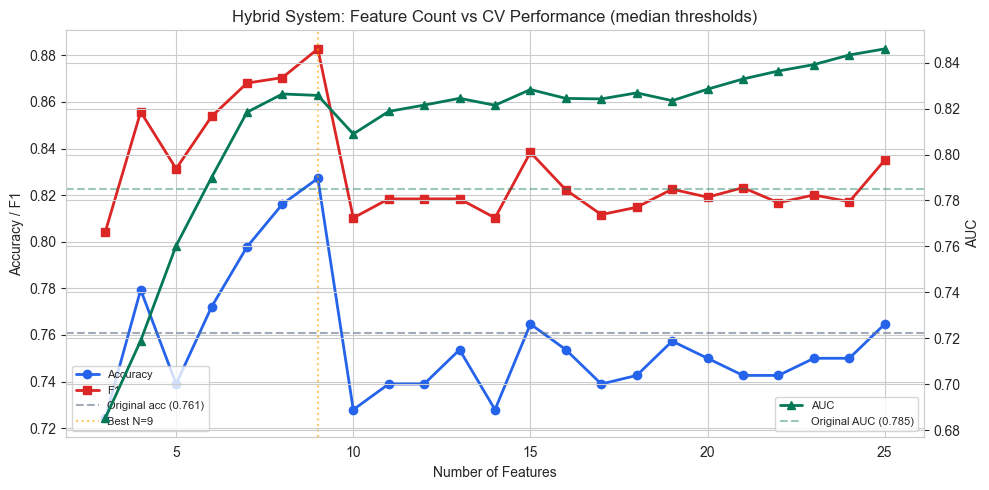

In [16]:
# Plot feature count vs performance
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(df_topn['n_features'], df_topn['acc'], 'o-', color='#2563eb', label='Accuracy', lw=2)
ax1.plot(df_topn['n_features'], df_topn['f1'], 's-', color='#dc2626', label='F1', lw=2)
ax2.plot(df_topn['n_features'], df_topn['auc'], '^-', color='#047857', label='AUC', lw=2)

ax1.axhline(0.761, color='#64748b', ls='--', alpha=0.6, label='Original acc (0.761)')
ax2.axhline(0.785, color='#047857', ls='--', alpha=0.4, label='Original AUC (0.785)')
ax1.axvline(best_row['n_features'], color='orange', ls=':', alpha=0.6, label=f'Best N={int(best_row["n_features"])}')

ax1.set_xlabel('Number of Features')
ax1.set_ylabel('Accuracy / F1')
ax2.set_ylabel('AUC')
ax1.legend(loc='lower left', fontsize=8)
ax2.legend(loc='lower right', fontsize=8)
ax1.set_title('Hybrid System: Feature Count vs CV Performance (median thresholds)')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'feature_count_optimisation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Final recommended system using best N features with median thresholds
best_n = int(best_row['n_features'])
final_features = selected[:best_n]
final_d_signs = d_signs_all[:best_n]
final_weights = weights_all[:best_n]

print(f'=== RECOMMENDED SYSTEM: {best_n} features, median thresholds, Cohen d weights ===\n')
print(f'{"#":>3s}  {"Feature":30s}  {"Direction":>10s}  {"Weight (|d|)":>12s}')
print('-' * 62)
for i, feat in enumerate(final_features):
    direction = 'higher→ON' if final_d_signs[i] > 0 else 'lower→ON'
    print(f'{i+1:3d}  {feat:30s}  {direction:>10s}  {final_weights[i]:12.3f}')

# Final OOF evaluation
oof_final_scores = np.zeros(len(dfa))
oof_final_preds = np.zeros(len(dfa))
fold_accs_final = []

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(dfa, y_a, groups)):
    df_tr, df_va = dfa.iloc[tr_idx], dfa.iloc[va_idx]
    y_tr, y_va = y_a[tr_idx], y_a[va_idx]

    medians = [np.nanmedian(df_tr[f].values.astype(float)) for f in final_features]

    sc = np.zeros(len(df_va))
    max_sc = 0
    for j, feat in enumerate(final_features):
        vals = df_va[feat].values.astype(float)
        if final_d_signs[j] > 0:
            vote = (vals >= medians[j]).astype(float)
        else:
            vote = (vals < medians[j]).astype(float)
        vote[np.isnan(vals)] = 0.0
        sc += vote * final_weights[j]
        max_sc += final_weights[j]

    sc_norm = sc / (max_sc + EPS)
    oof_final_scores[va_idx] = sc_norm

    # Threshold from training
    sc_tr = np.zeros(len(df_tr))
    for j, feat in enumerate(final_features):
        vals = df_tr[feat].values.astype(float)
        if final_d_signs[j] > 0:
            vote = (vals >= medians[j]).astype(float)
        else:
            vote = (vals < medians[j]).astype(float)
        vote[np.isnan(vals)] = 0.0
        sc_tr += vote * final_weights[j]
    sc_tr_norm = sc_tr / (max_sc + EPS)
    t_fold, _, _ = best_threshold_scan(sc_tr_norm, y_tr)

    pred = (sc_norm >= t_fold).astype(int)
    oof_final_preds[va_idx] = pred
    fold_accs_final.append(accuracy_score(y_va, pred))

auc_final = roc_auc_score(y_a, oof_final_scores)
acc_final = accuracy_score(y_a, oof_final_preds)
f1_final = f1_score(y_a, oof_final_preds, zero_division=0)
cm_final = confusion_matrix(y_a, oof_final_preds)

print(f'\n--- Cross-Validated Performance ---')
print(f'  Accuracy: {acc_final:.3f} ± {np.std(fold_accs_final):.3f}')
print(f'  F1:       {f1_final:.3f}')
print(f'  AUC:      {auc_final:.3f}')
print(f'  Confusion matrix:\n{cm_final}')
print(f'\nvs Original system: acc=0.761, F1=0.823, AUC=0.785')
print(f'   Improvement: acc {acc_final - 0.761:+.3f}, AUC {auc_final - 0.785:+.3f}')

=== RECOMMENDED SYSTEM: 9 features, median thresholds, Cohen d weights ===

  #  Feature                          Direction  Weight (|d|)
--------------------------------------------------------------
  1  ssn_B1                           higher→ON         0.856
  2  lr B2 B4                         higher→ON         0.841
  3  slope_diff_B1_B2                  lower→ON         0.757
  4  rolloff_norm_B3                   lower→ON         0.743
  5  spectral spread                   lower→ON         0.715
  6  spectral slope norm               lower→ON         0.700
  7  curvature_B2                     higher→ON         0.691
  8  lr B3 B4                         higher→ON         0.665
  9  slope_loglog_B3                   lower→ON         0.642



--- Cross-Validated Performance ---
  Accuracy: 0.827 ± 0.080
  F1:       0.883
  AUC:      0.826
  Confusion matrix:
[[ 48  36]
 [ 11 177]]

vs Original system: acc=0.761, F1=0.823, AUC=0.785
   Improvement: acc +0.066, AUC +0.041


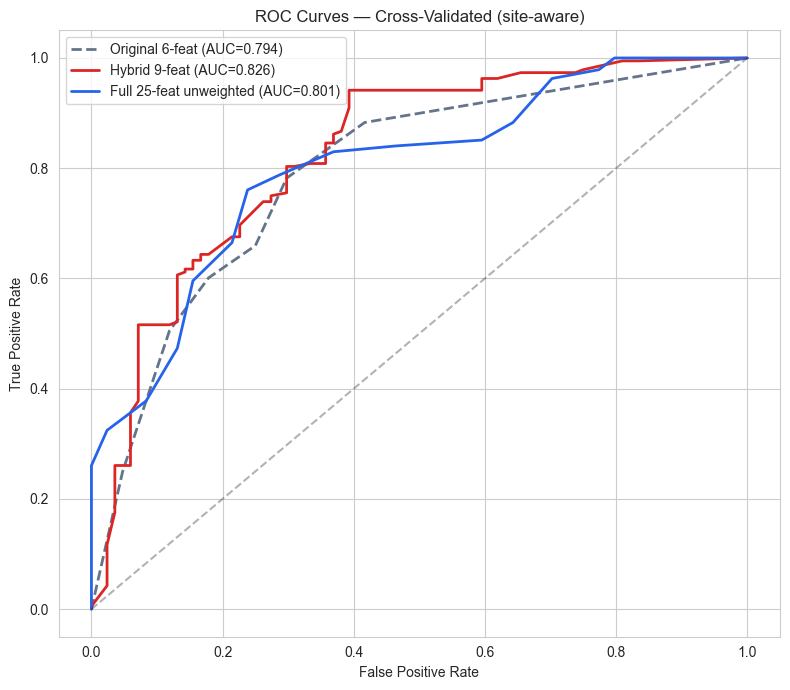

In [18]:
# ROC comparison: original vs hybrid
fig, ax = plt.subplots(figsize=(8, 7))

fpr_o, tpr_o, _ = roc_curve(y_a, oof_scores['original'])
auc_o = roc_auc_score(y_a, oof_scores['original'])
ax.plot(fpr_o, tpr_o, color='#64748b', ls='--', lw=2, label=f'Original 6-feat (AUC={auc_o:.3f})')

fpr_h, tpr_h, _ = roc_curve(y_a, oof_final_scores)
ax.plot(fpr_h, tpr_h, color='#dc2626', ls='-', lw=2, label=f'Hybrid {best_n}-feat (AUC={auc_final:.3f})')

fpr_u, tpr_u, _ = roc_curve(y_a, oof_scores['unweighted'])
auc_u = roc_auc_score(y_a, oof_scores['unweighted'])
ax.plot(fpr_u, tpr_u, color='#2563eb', ls='-', lw=2, label=f'Full 25-feat unweighted (AUC={auc_u:.3f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Cross-Validated (site-aware)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'roc_final.png'), dpi=150, bbox_inches='tight')
plt.show()

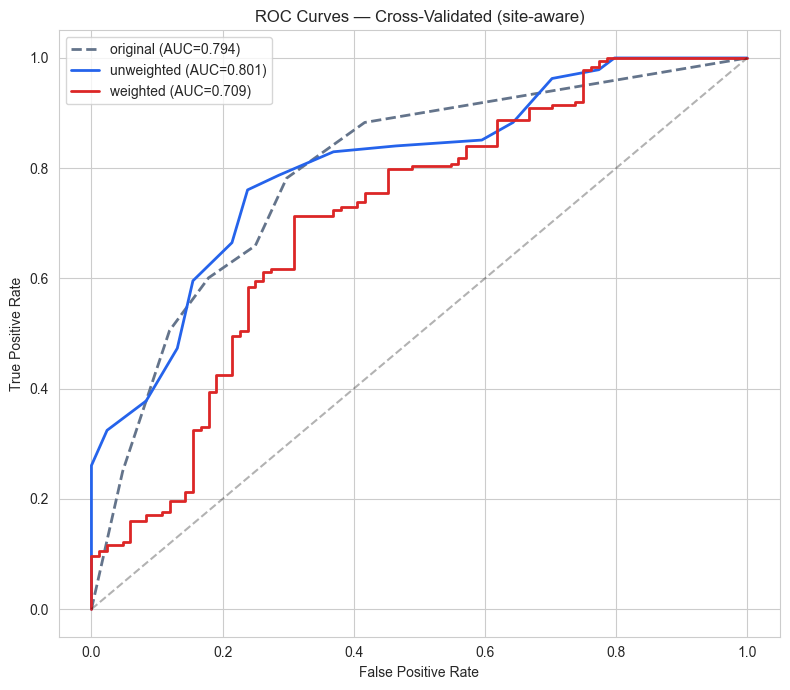

In [19]:
# ROC curves comparison
fig, ax = plt.subplots(figsize=(8, 7))
for name, color, ls in [('original', '#64748b', '--'), ('unweighted', '#2563eb', '-'), ('weighted', '#dc2626', '-')]:
    fpr, tpr, _ = roc_curve(y_a, oof_scores[name])
    auc_val = roc_auc_score(y_a, oof_scores[name])
    ax.plot(fpr, tpr, color=color, ls=ls, lw=2, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Cross-Validated (site-aware)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'roc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8 — Per-Site Analysis

In [20]:
site_comparison = []
for site, grp in dfa.groupby('site'):
    if grp['y'].nunique() < 2:
        continue
    y_site = grp['y'].values
    idx_site = grp.index
    pos = dfa.index.get_indexer(idx_site)

    for name in ['original', 'unweighted', 'weighted']:
        preds = oof_preds[name][pos]
        site_comparison.append({
            'site': site, 'system': name,
            'n': len(grp), 'n_ON': y_site.sum(), 'n_OFF': (y_site==0).sum(),
            'accuracy': accuracy_score(y_site, preds),
            'f1': f1_score(y_site, preds, zero_division=0)
        })

df_site_comp = pd.DataFrame(site_comparison)
df_pivot = df_site_comp.pivot_table(index=['site','n','n_ON','n_OFF'], columns='system', values='accuracy').reset_index()
df_pivot = df_pivot.sort_values('weighted', ascending=True)
print('Per-site accuracy comparison (OOF):')
print(df_pivot.to_string(index=False))

Per-site accuracy comparison (OOF):
         site  n  n_ON  n_OFF  original  unweighted  weighted
      Decatur 10     9      1  0.900000    0.100000  0.100000
      Van_GT3 19     3     16  0.526316    0.157895  0.157895
         WBN2  4     3      1  0.000000    0.000000  0.250000
  EMSA_GT2_NG  3     2      1  0.333333    0.333333  0.333333
      Van_GT4 20     1     19  0.950000    0.450000  0.350000
     Harq_ST3  9     5      4  0.666667    0.444444  0.444444
      Van_GT2 20    18      2  0.700000    1.000000  0.450000
     AEP_Turk  2     1      1  0.000000    0.500000  0.500000
      HARQCT3  2     1      1  1.000000    1.000000  0.500000
  EMSA_GT1_ng  2     1      1  0.500000    1.000000  0.500000
      HARQST2  2     1      1  1.000000    0.500000  0.500000
         VAN1 10     5      5  0.900000    1.000000  0.600000
         SQN2 15    10      5  0.666667    0.866667  0.666667
 Towantic_GT2  3     2      1  0.333333    0.333333  0.666667
Middletown_ST  3     2      1  0.6

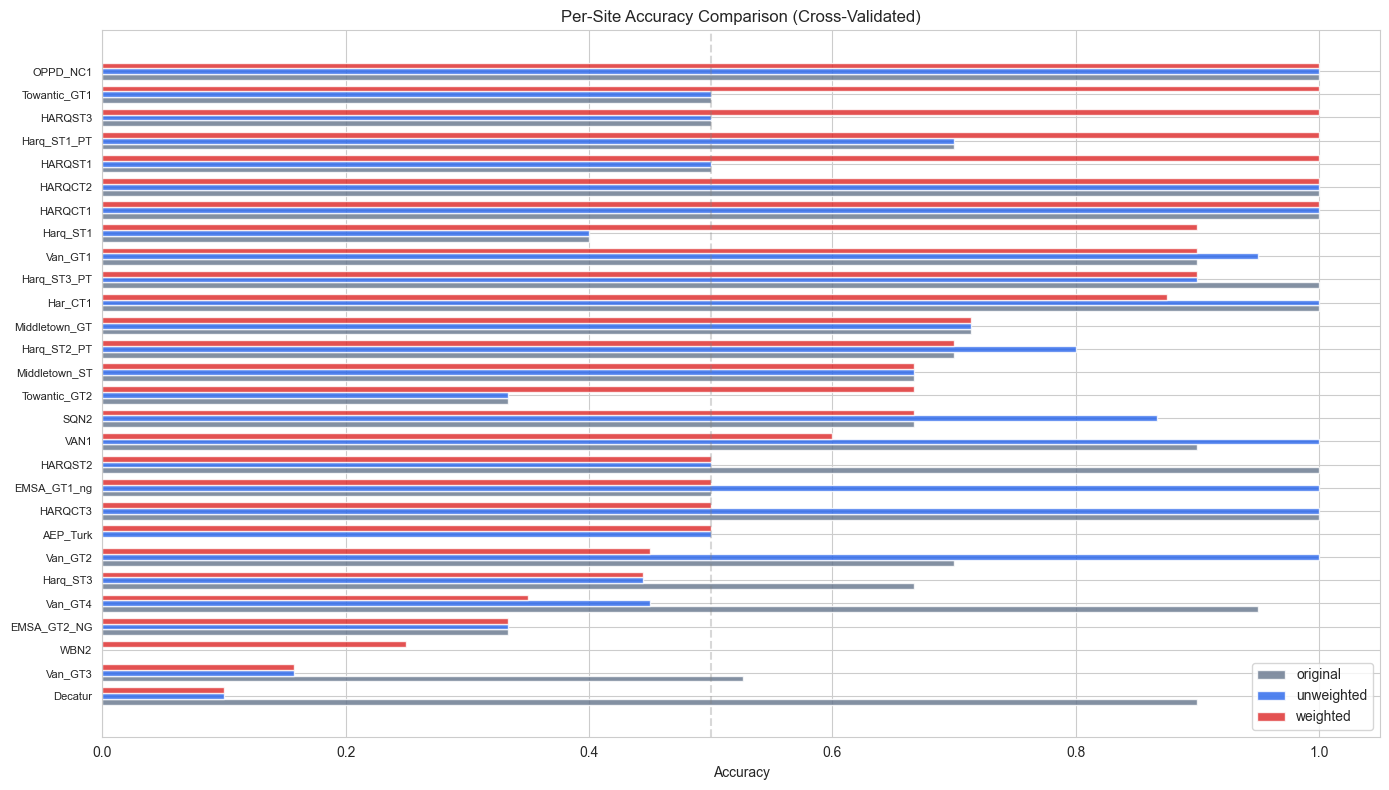

In [21]:
# Per-site bar chart
fig, ax = plt.subplots(figsize=(14, 8))
sites_order = df_pivot['site'].values
x = np.arange(len(sites_order))
w = 0.25

for i, (name, color) in enumerate([('original', '#64748b'), ('unweighted', '#2563eb'), ('weighted', '#dc2626')]):
    if name in df_pivot.columns:
        vals = df_pivot[name].values
        ax.barh(x + i*w, vals, height=w, label=name, color=color, alpha=0.8)

ax.set_yticks(x + w)
ax.set_yticklabels(sites_order, fontsize=8)
ax.set_xlabel('Accuracy')
ax.set_title('Per-Site Accuracy Comparison (Cross-Validated)')
ax.legend()
ax.axvline(0.5, color='grey', ls='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'per_site_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9 — Feature Distribution Analysis (ON vs OFF)

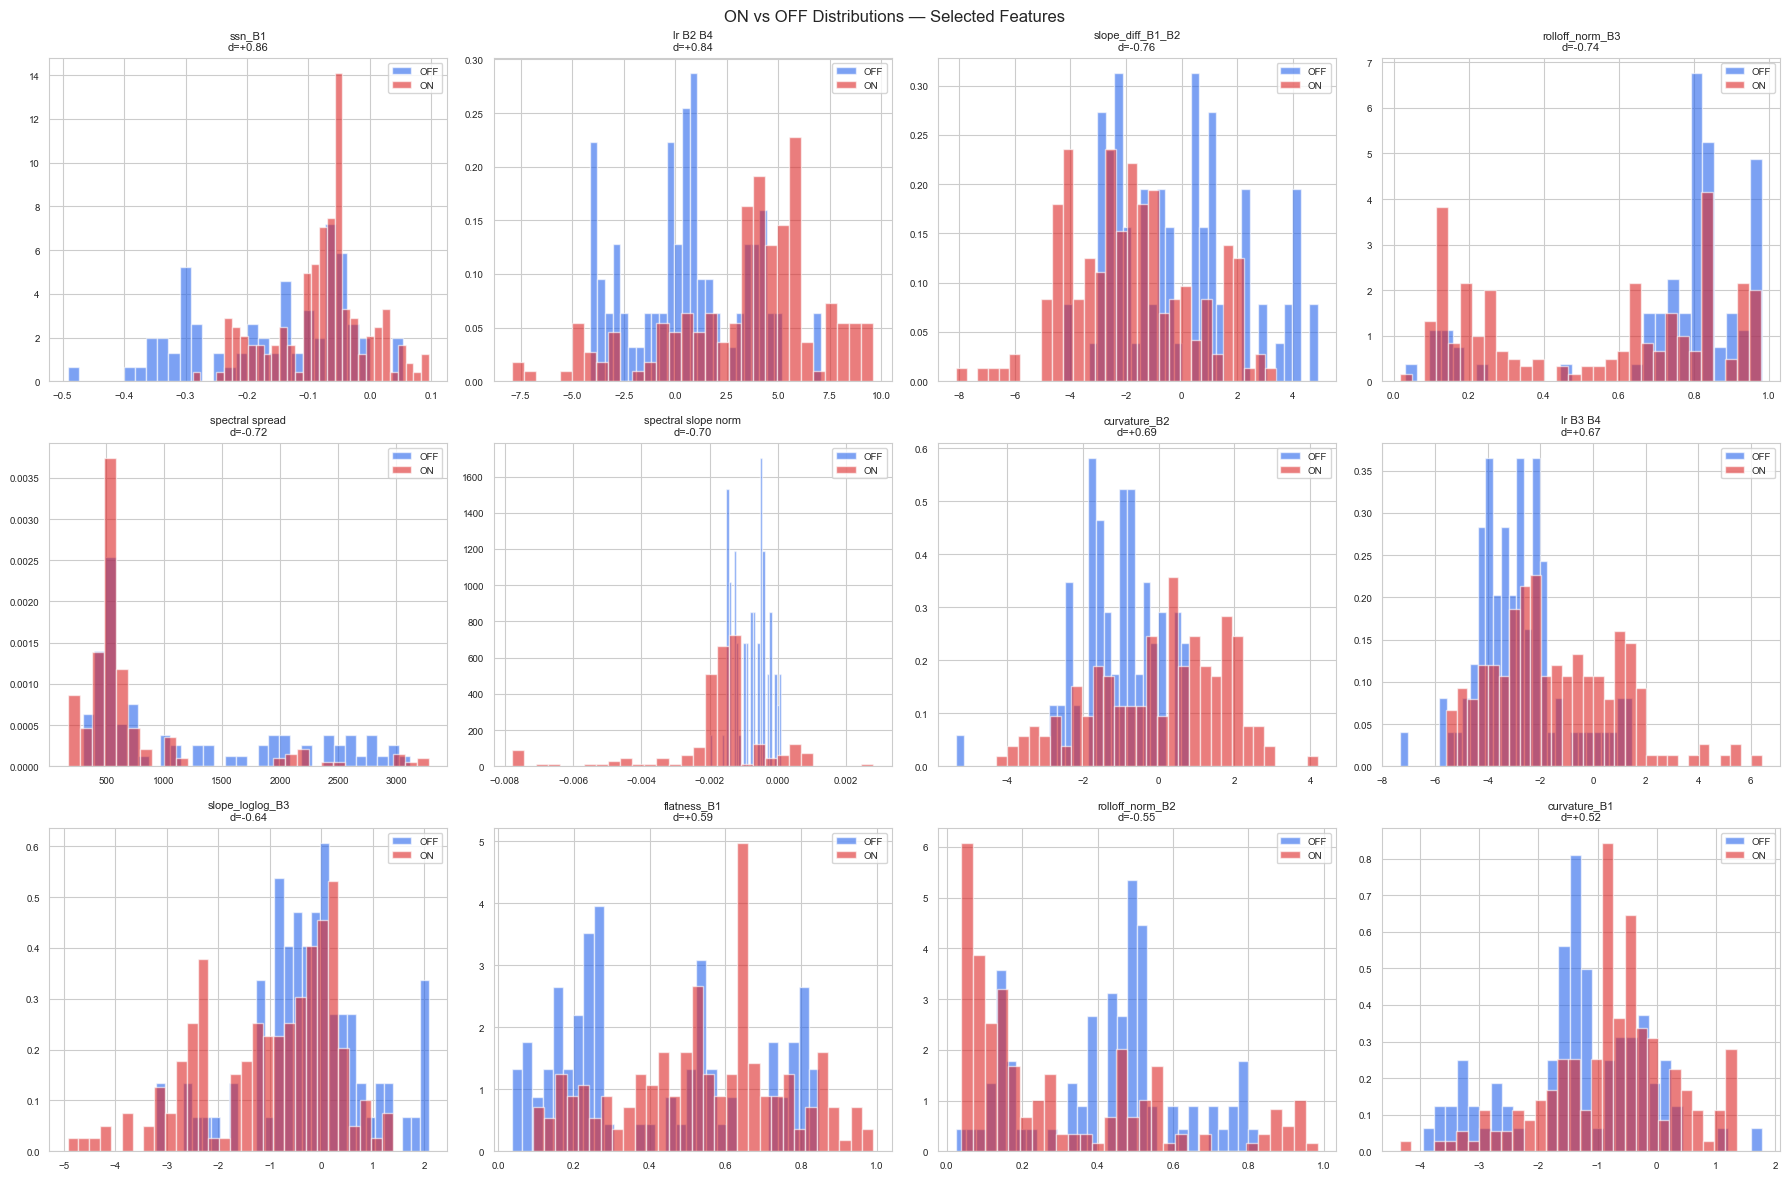

In [22]:
# Distribution plots for top selected features
n_plot = min(12, len(selected))
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, feat in enumerate(selected[:n_plot]):
    ax = axes[i]
    on_vals = dfa.loc[on_mask, feat].dropna()
    off_vals = dfa.loc[off_mask, feat].dropna()
    ax.hist(off_vals, bins=30, alpha=0.6, color='#2563eb', label='OFF', density=True)
    ax.hist(on_vals, bins=30, alpha=0.6, color='#dc2626', label='ON', density=True)
    d_val = df_stats[df_stats['feature']==feat]['cohen_d'].values[0]
    ax.set_title(f'{feat}\nd={d_val:+.2f}', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(n_plot, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ON vs OFF Distributions — Selected Features', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10 — Score Distribution & Decision Boundary

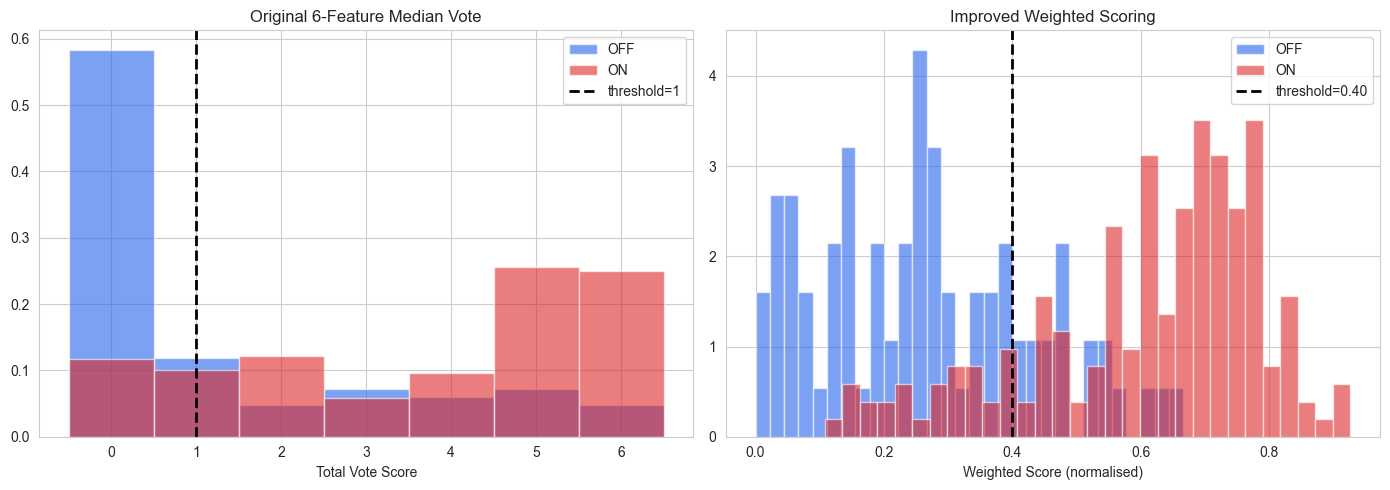

In [23]:
# Score distribution for weighted system
# Recompute in-sample scores for visualisation
scores_w_all, max_w_all = compute_scores(dfa, df_scoring, mode='weighted')
scores_w_all_norm = scores_w_all / (max_w_all + EPS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original system
ax = axes[0]
orig_on = dfa.loc[on_mask, '_old_total']
orig_off = dfa.loc[off_mask, '_old_total']
bins = np.arange(-0.5, 7.5, 1)
ax.hist(orig_off, bins=bins, alpha=0.6, color='#2563eb', label='OFF', density=True)
ax.hist(orig_on, bins=bins, alpha=0.6, color='#dc2626', label='ON', density=True)
ax.axvline(best_t, color='black', ls='--', lw=2, label=f'threshold={best_t}')
ax.set_xlabel('Total Vote Score')
ax.set_title('Original 6-Feature Median Vote')
ax.legend()

# Improved weighted system
ax = axes[1]
ax.hist(scores_w_all_norm[off_mask], bins=30, alpha=0.6, color='#2563eb', label='OFF', density=True)
ax.hist(scores_w_all_norm[on_mask], bins=30, alpha=0.6, color='#dc2626', label='ON', density=True)
ax.axvline(t_w, color='black', ls='--', lw=2, label=f'threshold={t_w:.2f}')
ax.set_xlabel('Weighted Score (normalised)')
ax.set_title('Improved Weighted Scoring')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'score_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11 — New Feature Deep-Dive: Band-Level Slopes

Band-level slope features vs running state:
Feature                           mean_ON   mean_OFF    Cohen d      AUC         MW p
----------------------------------------------------------------------------------
slope_loglog_B1                   -1.1178    -1.7514     +0.566    0.630     1.23e-03
slope_loglog_B2                   -2.9669    -1.8968     -0.686    0.691     2.64e-06
slope_loglog_B3                   -1.0186    -0.2063     -0.642    0.657     9.15e-05
slope_loglog_B4                   -1.4790    -1.4041     -0.044    0.531     4.71e-01
ssn_B1                            -0.0781    -0.1580     +0.856    0.679     9.08e-06
ssn_B2                            -0.2069    -0.1549     -0.442    0.603     1.01e-02
ssn_B3                            -0.0685    -0.0172     -0.585    0.642     4.04e-04
ssn_B4                            -0.1031    -0.1125     +0.078    0.509     8.41e-01


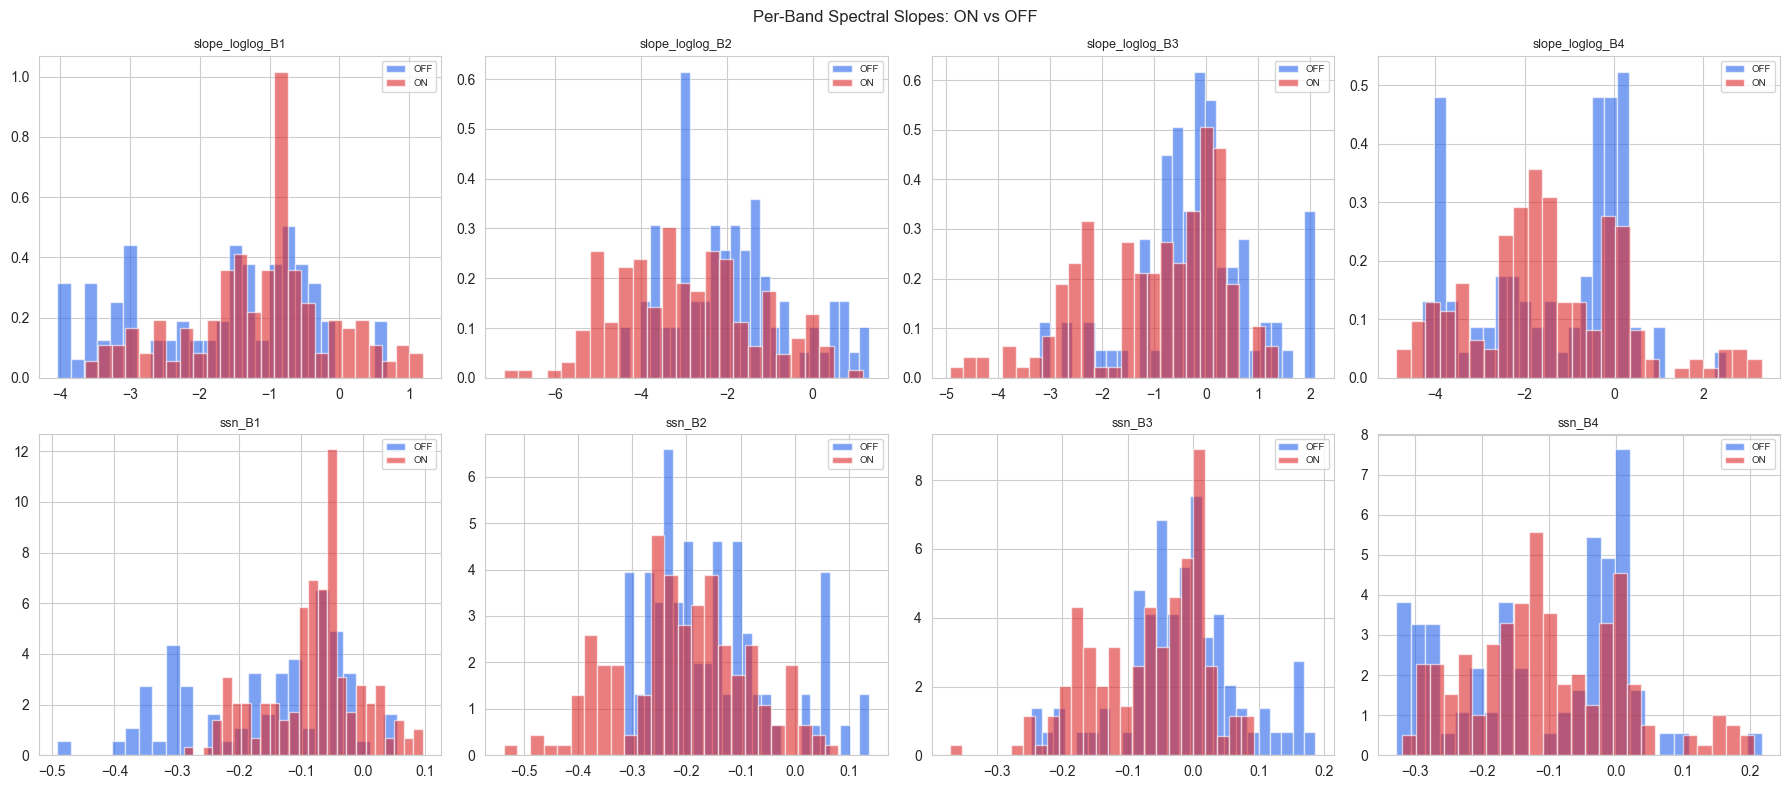

In [24]:
# Analyse per-band spectral slopes in detail
slope_feats = [f'slope_loglog_{bn}' for bn in BANDS] + [f'ssn_{bn}' for bn in BANDS]
slope_feats = [f for f in slope_feats if f in dfa.columns]

print('Band-level slope features vs running state:')
print(f'{"Feature":30s} {"mean_ON":>10s} {"mean_OFF":>10s} {"Cohen d":>10s} {"AUC":>8s} {"MW p":>12s}')
print('-' * 82)
for feat in slope_feats:
    row = df_stats[df_stats['feature'] == feat]
    if len(row) == 0:
        continue
    r = row.iloc[0]
    print(f'{feat:30s} {r["mean_ON"]:10.4f} {r["mean_OFF"]:10.4f} {r["cohen_d"]:+10.3f} {r["AUC_abs"]:8.3f} {r["MW_p_BH"]:12.2e}')

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, feat in enumerate(slope_feats[:8]):
    ax = axes.ravel()[i]
    on_v = dfa.loc[on_mask, feat].dropna()
    off_v = dfa.loc[off_mask, feat].dropna()
    ax.hist(off_v, bins=25, alpha=0.6, color='#2563eb', label='OFF', density=True)
    ax.hist(on_v, bins=25, alpha=0.6, color='#dc2626', label='ON', density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Per-Band Spectral Slopes: ON vs OFF', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'band_slopes.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12 — Summary & Export

In [25]:
# Save comprehensive results
os.makedirs(os.path.join(ROOT, 'src', '_scoring_figs'), exist_ok=True)

# Export scoring parameters
df_scoring.to_csv(os.path.join(ROOT, 'data', 'scoring_parameters.csv'), index=False)

# Export full statistics table
df_stats.to_csv(os.path.join(ROOT, 'data', 'feature_association_stats.csv'), index=False)

# Export augmented dataset with new features + scores
dfa['score_weighted'] = scores_w_all_norm
dfa['score_unweighted'] = scores_u / (max_u + EPS)
dfa['pred_weighted'] = (scores_w_all_norm >= t_w).astype(int)
dfa['pred_unweighted'] = (scores_u / (max_u + EPS) >= t_u).astype(int)

export_cols = (['site', 'spectrum id', 'running state', 'y'] +
               scoring_features +
               ['_old_total', 'score_weighted', 'score_unweighted', 'pred_weighted', 'pred_unweighted'])
export_cols = [c for c in export_cols if c in dfa.columns]
dfa[export_cols].to_csv(os.path.join(ROOT, 'data', 'improved_scoring_results.csv'), index=False)

print('Exported:')
print(f'  data/scoring_parameters.csv         ({len(df_scoring)} features)')
print(f'  data/feature_association_stats.csv   ({len(df_stats)} features)')
print(f'  data/improved_scoring_results.csv    ({len(dfa)} spectrums)')

Exported:
  data/scoring_parameters.csv         (25 features)
  data/feature_association_stats.csv   (77 features)
  data/improved_scoring_results.csv    (272 spectrums)


In [26]:
# Final summary
print('=' * 70)
print('ANALYSIS SUMMARY')
print('=' * 70)
print(f'\nDataset: {len(dfa)} labeled spectrums ({(y_a==1).sum()} ON / {(y_a==0).sum()} OFF)')
print(f'Sites: {dfa["site"].nunique()}')
print(f'\nFeatures tested: {len(df_stats)}')
print(f'  Original features: {(df_stats["source"]=="original").sum()}')
print(f'  New band-level features: {(df_stats["source"]=="new").sum()}')
print(f'  Significant (BH p<0.05): {df_stats["significant"].sum()}')
print(f'\nSelected non-redundant features: {len(selected)}')
print(f'\n--- Cross-Validated Performance (5-fold site-aware) ---')
for name in ['original', 'unweighted', 'weighted']:
    df_cv = pd.DataFrame(cv_results[name])
    auc_oof = roc_auc_score(y_a, oof_scores[name])
    prec = precision_score(y_a, oof_preds[name], zero_division=0)
    rec = recall_score(y_a, oof_preds[name], zero_division=0)
    f1_oof = f1_score(y_a, oof_preds[name], zero_division=0)
    print(f'  {name:15s}: acc={df_cv["accuracy"].mean():.3f}±{df_cv["accuracy"].std():.3f}  '
          f'F1={f1_oof:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  AUC={auc_oof:.3f}')
print(f'\nScoring features and weights saved to data/scoring_parameters.csv')
print('=' * 70)

ANALYSIS SUMMARY

Dataset: 272 labeled spectrums (188 ON / 84 OFF)
Sites: 38

Features tested: 77
  Original features: 29
  New band-level features: 48
  Significant (BH p<0.05): 52

Selected non-redundant features: 25

--- Cross-Validated Performance (5-fold site-aware) ---
  original       : acc=0.792±0.077  F1=0.853  Prec=0.826  Rec=0.883  AUC=0.794
  unweighted     : acc=0.720±0.173  F1=0.810  Prec=0.792  Rec=0.830  AUC=0.801
  weighted       : acc=0.657±0.148  F1=0.764  Prec=0.746  Rec=0.782  AUC=0.709

Scoring features and weights saved to data/scoring_parameters.csv


## 13 — Previous 5-Feature System Comparison

Apply the original 5-feature weighted scoring system (from the first analysis run) to the updated 272-spectrum dataset, using the previously computed weights, and compare against the current 9-feature system.

In [27]:
# Previous 5-feature system (weights from first analysis on 230 spectrums)
prev5_features = ['ssn_B1', 'lr B2 B4', 'spectral spread', 'rolloff_norm_B3', 'curvature_B2']
prev5_directions = ['higher', 'higher', 'lower', 'lower', 'higher']
prev5_weights = [0.945, 0.839, 0.811, 0.738, 0.719]  # original Cohen's d weights

prev5_params = pd.DataFrame({
    'feature': prev5_features,
    'direction': prev5_directions,
    'weight': prev5_weights,
})

print('=== Previous 5-Feature System (fixed weights from first run) ===')
print(prev5_params.to_string(index=False))
print()

# Cross-validated evaluation using the same folds
oof_preds_prev5 = np.zeros(len(dfa))
oof_scores_prev5 = np.zeros(len(dfa))
fold_accs_prev5 = []

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(dfa, y_a, groups)):
    df_tr, df_va = dfa.iloc[tr_idx], dfa.iloc[va_idx]
    y_tr, y_va = y_a[tr_idx], y_a[va_idx]

    # Median thresholds from training fold
    medians_fold = {f: np.nanmedian(df_tr[f].values.astype(float)) for f in prev5_features}

    sc = np.zeros(len(df_va))
    max_sc = sum(prev5_weights)
    for j, feat in enumerate(prev5_features):
        vals = df_va[feat].values.astype(float)
        med = medians_fold[feat]
        if prev5_directions[j] == 'higher':
            vote = (vals >= med).astype(float)
        else:
            vote = (vals < med).astype(float)
        vote[np.isnan(vals)] = 0.0
        sc += vote * prev5_weights[j]

    sc_norm = sc / (max_sc + EPS)
    oof_scores_prev5[va_idx] = sc_norm

    # Threshold from training fold
    sc_tr = np.zeros(len(df_tr))
    for j, feat in enumerate(prev5_features):
        vals = df_tr[feat].values.astype(float)
        med = medians_fold[feat]
        if prev5_directions[j] == 'higher':
            vote = (vals >= med).astype(float)
        else:
            vote = (vals < med).astype(float)
        vote[np.isnan(vals)] = 0.0
        sc_tr += vote * prev5_weights[j]
    sc_tr_norm = sc_tr / (max_sc + EPS)
    t_fold, _, _ = best_threshold_scan(sc_tr_norm, y_tr)

    pred = (sc_norm >= t_fold).astype(int)
    oof_preds_prev5[va_idx] = pred
    fold_accs_prev5.append(accuracy_score(y_va, pred))

# Metrics
acc_prev5 = accuracy_score(y_a, oof_preds_prev5)
f1_prev5 = f1_score(y_a, oof_preds_prev5, zero_division=0)
prec_prev5 = precision_score(y_a, oof_preds_prev5, zero_division=0)
rec_prev5 = recall_score(y_a, oof_preds_prev5, zero_division=0)
auc_prev5 = roc_auc_score(y_a, oof_scores_prev5)
cm_prev5 = confusion_matrix(y_a, oof_preds_prev5)

print('--- Cross-Validated Performance (5-fold site-aware) ---')
print(f'  Accuracy:  {acc_prev5:.3f} ± {np.std(fold_accs_prev5):.3f}')
print(f'  F1:        {f1_prev5:.3f}')
print(f'  Precision: {prec_prev5:.3f}')
print(f'  Recall:    {rec_prev5:.3f}')
print(f'  AUC:       {auc_prev5:.3f}')
print(f'\nConfusion matrix:\n{cm_prev5}')
print(f'\n{classification_report(y_a, oof_preds_prev5, target_names=["OFF","ON"])}')

=== Previous 5-Feature System (fixed weights from first run) ===
        feature direction  weight
         ssn_B1    higher   0.945
       lr B2 B4    higher   0.839
spectral spread     lower   0.811
rolloff_norm_B3     lower   0.738
   curvature_B2    higher   0.719



--- Cross-Validated Performance (5-fold site-aware) ---
  Accuracy:  0.831 ± 0.071
  F1:        0.886
  Precision: 0.832
  Recall:    0.947
  AUC:       0.819

Confusion matrix:
[[ 48  36]
 [ 10 178]]

              precision    recall  f1-score   support

         OFF       0.83      0.57      0.68        84
          ON       0.83      0.95      0.89       188

    accuracy                           0.83       272
   macro avg       0.83      0.76      0.78       272
weighted avg       0.83      0.83      0.82       272



In [28]:
# Side-by-side comparison table
print('=' * 80)
print('SYSTEM COMPARISON — Cross-Validated (5-fold site-aware, 272 spectrums)')
print('=' * 80)
print()
print(f'{"System":<30s} {"Acc":>7s} {"F1":>7s} {"Prec":>7s} {"Rec":>7s} {"AUC":>7s} {"FN":>5s} {"FP":>5s}')
print('-' * 80)

systems = [
    ('Original 6-feat median', 0.792, 0.853, 0.826, 0.883, 0.794,
     int(cm_oof[1,0]) if 'cm_oof' in dir() else 22, int(cm_oof[0,1]) if 'cm_oof' in dir() else 35),
]

# Original system
acc_o = accuracy_score(y_a, oof_preds['original'])
f1_o = f1_score(y_a, oof_preds['original'], zero_division=0)
prec_o = precision_score(y_a, oof_preds['original'], zero_division=0)
rec_o = recall_score(y_a, oof_preds['original'], zero_division=0)
auc_o = roc_auc_score(y_a, oof_scores['original'])
cm_o = confusion_matrix(y_a, oof_preds['original'])
print(f'{"Original 6-feat median":<30s} {acc_o:7.3f} {f1_o:7.3f} {prec_o:7.3f} {rec_o:7.3f} {auc_o:7.3f} {cm_o[1,0]:5d} {cm_o[0,1]:5d}')

# Previous 5-feat
print(f'{"Previous 5-feat weighted":<30s} {acc_prev5:7.3f} {f1_prev5:7.3f} {prec_prev5:7.3f} {rec_prev5:7.3f} {auc_prev5:7.3f} {cm_prev5[1,0]:5d} {cm_prev5[0,1]:5d}')

# Current 9-feat (from cell 25)
print(f'{"Current 9-feat weighted":<30s} {acc_final:7.3f} {f1_final:7.3f} {precision_score(y_a, oof_final_preds, zero_division=0):7.3f} {recall_score(y_a, oof_final_preds, zero_division=0):7.3f} {auc_final:7.3f} {cm_final[1,0]:5d} {cm_final[0,1]:5d}')
print('-' * 80)

SYSTEM COMPARISON — Cross-Validated (5-fold site-aware, 272 spectrums)

System                             Acc      F1    Prec     Rec     AUC    FN    FP
--------------------------------------------------------------------------------
Original 6-feat median           0.790   0.853   0.826   0.883   0.794    22    35
Previous 5-feat weighted         0.831   0.886   0.832   0.947   0.819    10    36
Current 9-feat weighted          0.827   0.883   0.831   0.941   0.826    11    36
--------------------------------------------------------------------------------


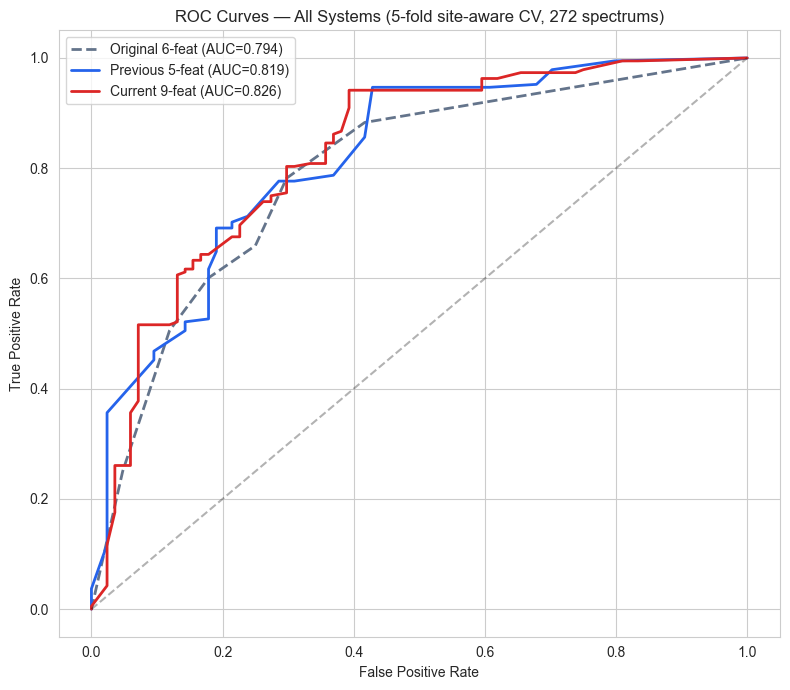

In [29]:
# ROC curves: all three systems
fig, ax = plt.subplots(figsize=(8, 7))

fpr_o, tpr_o, _ = roc_curve(y_a, oof_scores['original'])
ax.plot(fpr_o, tpr_o, color='#64748b', ls='--', lw=2, label=f'Original 6-feat (AUC={auc_o:.3f})')

fpr_p5, tpr_p5, _ = roc_curve(y_a, oof_scores_prev5)
ax.plot(fpr_p5, tpr_p5, color='#2563eb', ls='-', lw=2, label=f'Previous 5-feat (AUC={auc_prev5:.3f})')

fpr_f, tpr_f, _ = roc_curve(y_a, oof_final_scores)
ax.plot(fpr_f, tpr_f, color='#dc2626', ls='-', lw=2, label=f'Current 9-feat (AUC={auc_final:.3f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Systems (5-fold site-aware CV, 272 spectrums)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'src', '_scoring_figs', 'roc_all_systems.png'), dpi=150, bbox_inches='tight')
plt.show()